In [2]:
# Chcecking for GPU and CUDA version

import torch
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

True
11.8
NVIDIA GeForce RTX 4050 Laptop GPU


In [3]:
import torch
import torch.nn as nn
from torchvision import models
import torch.optim as optim

In [4]:
import os
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

In [5]:
# Importing the Dataset and creating dataloaders
base_dir = '.'

train_dataset = datasets.ImageFolder(root = os.path.join(base_dir, 'DATASET','TRAIN'), transform = transform)
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)

val_dataset = datasets.ImageFolder(root = os.path.join(base_dir, 'DATASET', 'TEST'), transform = transform)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle = False)

In [6]:
# Loadin the pre-trained ResNet50 model
base_model = models.resnet50(weights = models.ResNet50_Weights.DEFAULT)

In [43]:
# Freezing the layers
for param in base_model.parameters():
    param.requires_grad = False

In [7]:
# Replacing the final layer
num_ftrs = base_model.fc.in_features
base_model.fc = nn.Linear(num_ftrs, 2)

In [8]:
# Moving the model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_model = base_model.to(device)

In [46]:
# Optimizing the parameters of the New layers only
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(base_model.fc.parameters(), lr = 0.001)

In [47]:
# Defining the training loop of the model
epochs = 10
for epoch in range(epochs):
    base_model.train()
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = base_model(inputs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    print(f'Epoch {epoch + 1}/{epochs}, Loss : {loss.item(): .4f}')

Epoch 1/10, Loss :  0.0702
Epoch 2/10, Loss :  0.2154
Epoch 3/10, Loss :  0.1211
Epoch 4/10, Loss :  0.2404
Epoch 5/10, Loss :  0.3716
Epoch 6/10, Loss :  0.2448
Epoch 7/10, Loss :  1.2165
Epoch 8/10, Loss :  0.0985
Epoch 9/10, Loss :  0.0040
Epoch 10/10, Loss :  0.2638


In [57]:
# validating the model on the validation dataset

base_model.eval()

correct = 0
total = 0
val_loss = 0.0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = base_model(images)
        loss = criterion(outputs,labels)
        val_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
accuracy = 100 * correct/total
avg_loss = val_loss/ len(val_loader)

print(f'Validation Accuracy : {accuracy: .2f}%')
print(f'Validation Loss : {avg_loss: .4f}')

Validation Accuracy :  93.83%
Validation Loss :  0.1605


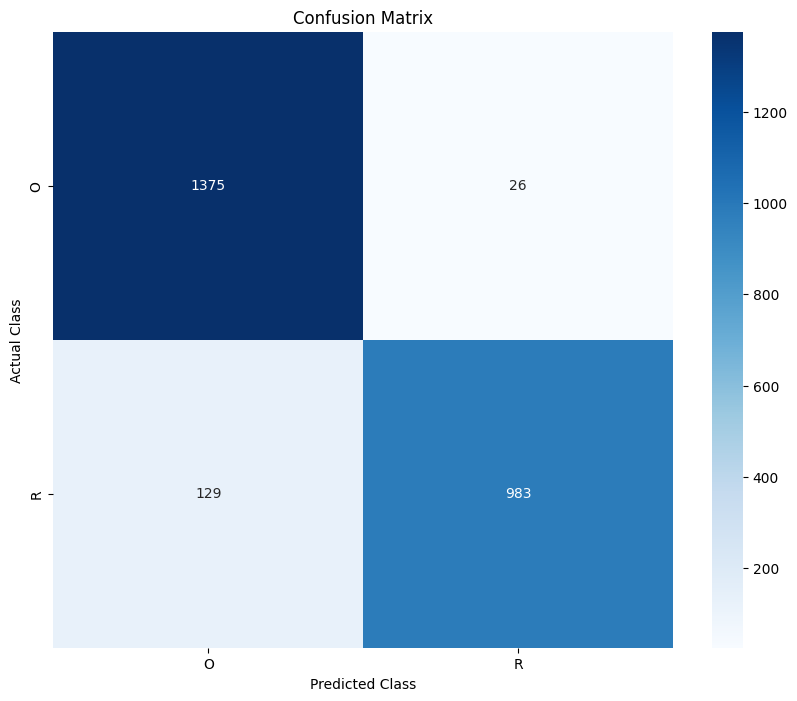

In [54]:
# Analyzing the Classification by the model
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

all_preds = []
all_labels = []

base_model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = base_model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Creating the confusion matrix

cm = confusion_matrix(all_labels, all_preds)
class_names = train_dataset.classes

# Plotting using Seaborn

plt.figure(figsize = (10,8))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = class_names,
            yticklabels = class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names = class_names))

              precision    recall  f1-score   support

           0       0.91      0.98      0.95      1401
           1       0.97      0.88      0.93      1112

    accuracy                           0.94      2513
   macro avg       0.94      0.93      0.94      2513
weighted avg       0.94      0.94      0.94      2513



In [9]:
for param in base_model.layer4.parameters():
    param.requires_grad = True

In [10]:
# Increasing the learning rate as we have unfrozen the last layer of the model
optimizer = optim.Adam(base_model.parameters(), lr = 1e-6)
criterion = nn.CrossEntropyLoss()

In [11]:
epochs = 10

for epoch in range(epochs):
    base_model.train()
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = base_model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    print(f'Epich {epoch + 1}/{epochs}, Loss : {loss.item(): .4f}')

Epich 1/10, Loss :  0.6182
Epich 2/10, Loss :  0.5248
Epich 3/10, Loss :  0.5936
Epich 4/10, Loss :  0.2093
Epich 5/10, Loss :  0.1490
Epich 6/10, Loss :  0.4437
Epich 7/10, Loss :  0.0656
Epich 8/10, Loss :  0.2147
Epich 9/10, Loss :  0.0643
Epich 10/10, Loss :  0.3531


In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

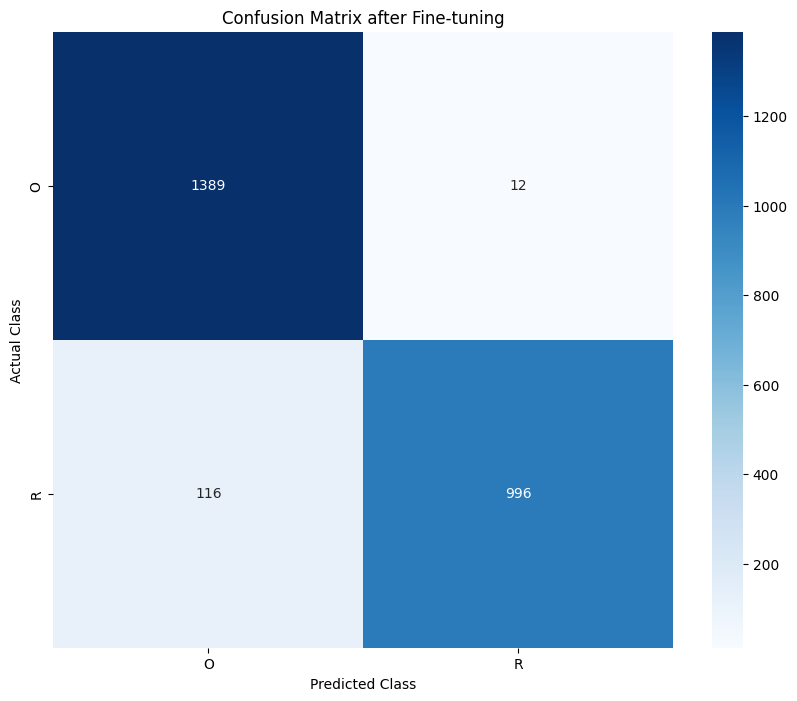

In [14]:
# Visualizing the confusion matrix of the fine-tuned model

# Collecting the predictions and labels for the validation dataset
all_preds = []
all_labels = []

base_model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = base_model(images)
        _, preds = torch.max(outputs,1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Creating the confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = train_dataset.classes

# Plotting the confusion matrix using seaborn
plt.figure(figsize = (10,8))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = class_names, yticklabels = class_names)
plt.title('Confusion Matrix after Fine-tuning')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

In [16]:
print(classification_report(all_labels, all_preds, target_names = class_names))

              precision    recall  f1-score   support

           O       0.92      0.99      0.96      1401
           R       0.99      0.90      0.94      1112

    accuracy                           0.95      2513
   macro avg       0.96      0.94      0.95      2513
weighted avg       0.95      0.95      0.95      2513



In [17]:
#Saving the weights of the fine-tuned model
model_save_path = 'fine-tuned-resnet50.pth'

# Save the state_dict (the weights)
torch.save(base_model.state_dict(), model_save_path)

print(f'Model weights saved successfully to {model_save_path}')

Model weights saved successfully to fine-tuned-resnet50.pth
